In [1]:
from sklearn.tree import DecisionTreeClassifier

In [2]:
from sklearn.datasets import load_digits

In [3]:
df=load_digits()

In [4]:
df

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [6]:
clf=DecisionTreeClassifier()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x=df.data
y=df.target

In [9]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [11]:
y_pred=clf.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score

In [13]:
accuracy=accuracy_score(y_pred,y_test)

In [14]:
accuracy

0.8638888888888889

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

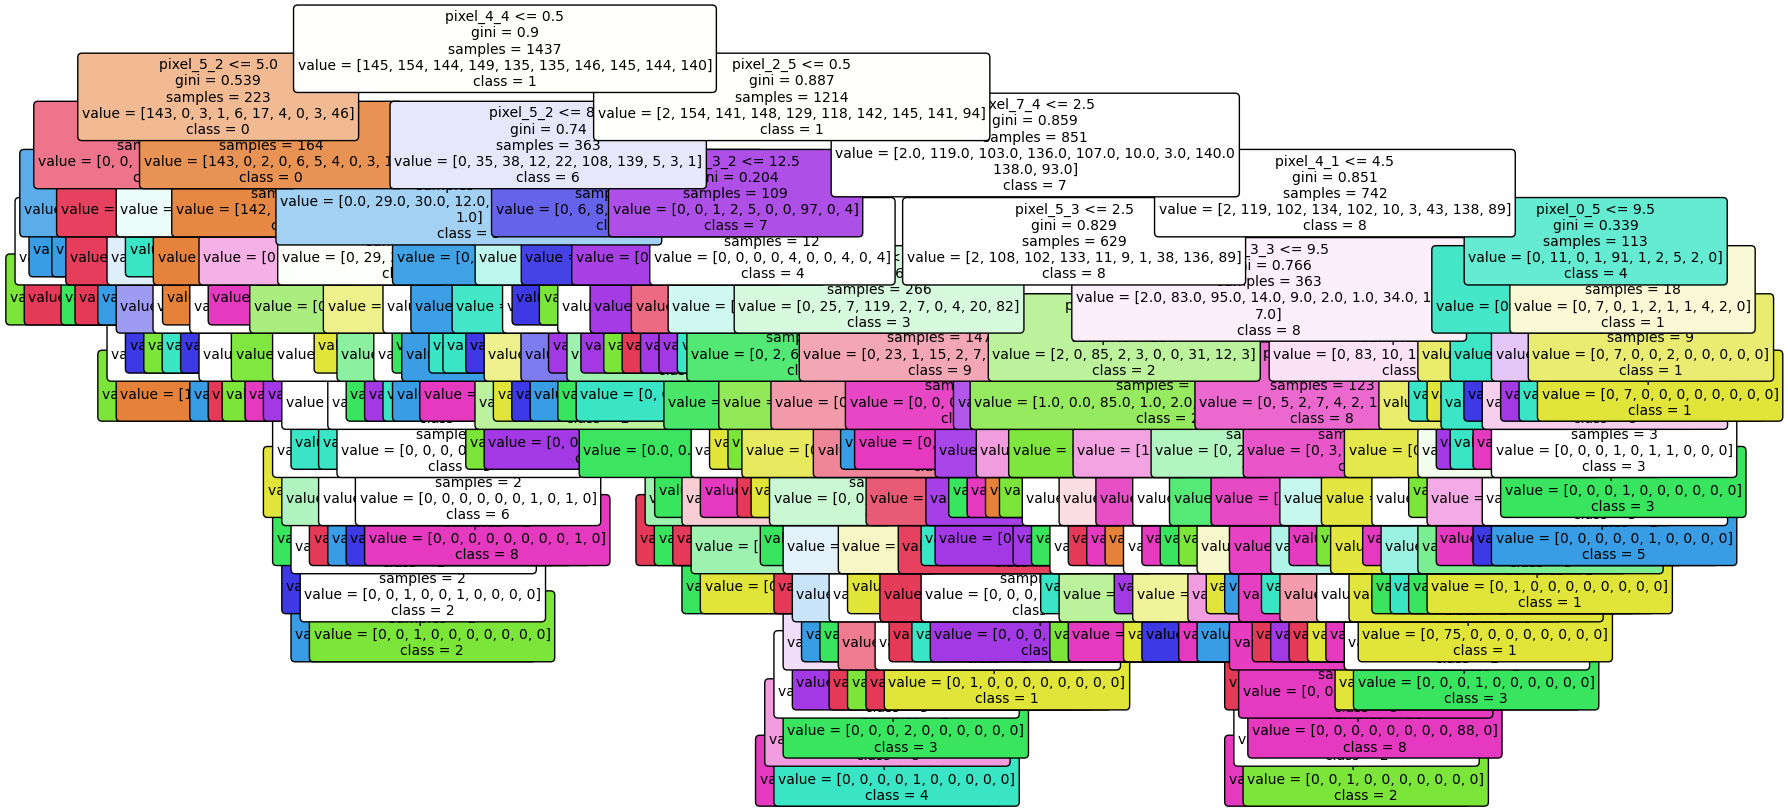

In [20]:
plt.figure(figsize=(20, 10)) 
plot_tree(clf, 
          filled=True, 
          feature_names=df.feature_names,
          class_names=[str(i) for i in df.target_names],
          fontsize=10,
          rounded=True)
plt.show()

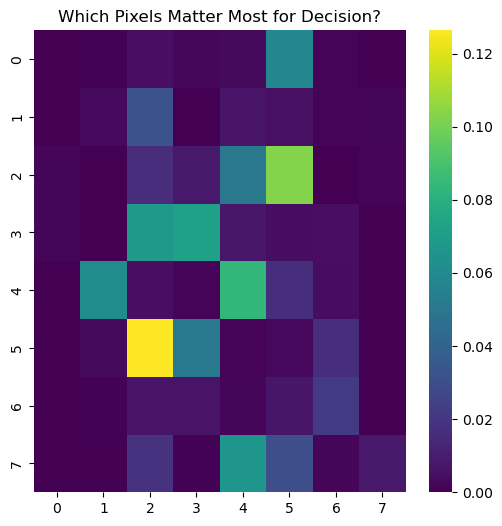

In [21]:
import seaborn as sns

importances = clf.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 6))
sns.heatmap(importances, cmap='viridis', annot=False)
plt.title("Which Pixels Matter Most for Decision?")
plt.show()

In [31]:
def visualize_tree(criterion='gini', splitter='best', max_depth=None, 
                   min_samples_split=2, min_samples_leaf=1):
    
    model = DecisionTreeClassifier(
        criterion=criterion,
        splitter=splitter,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # 2. Fit the model
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    print(f"Model Accuracy on Test Set: {acc:.2%}")
    print(f"Current Depth: {model.get_depth()}")

    plt.figure(figsize=(20, 10))
    plot_tree(model, 
              filled=True, 
              feature_names=df.feature_names,
              class_names=[str(i) for i in df.target_names],
              fontsize=10,
              rounded=True)
    plt.show()

Model Accuracy on Test Set: 78.06%
Current Depth: 5


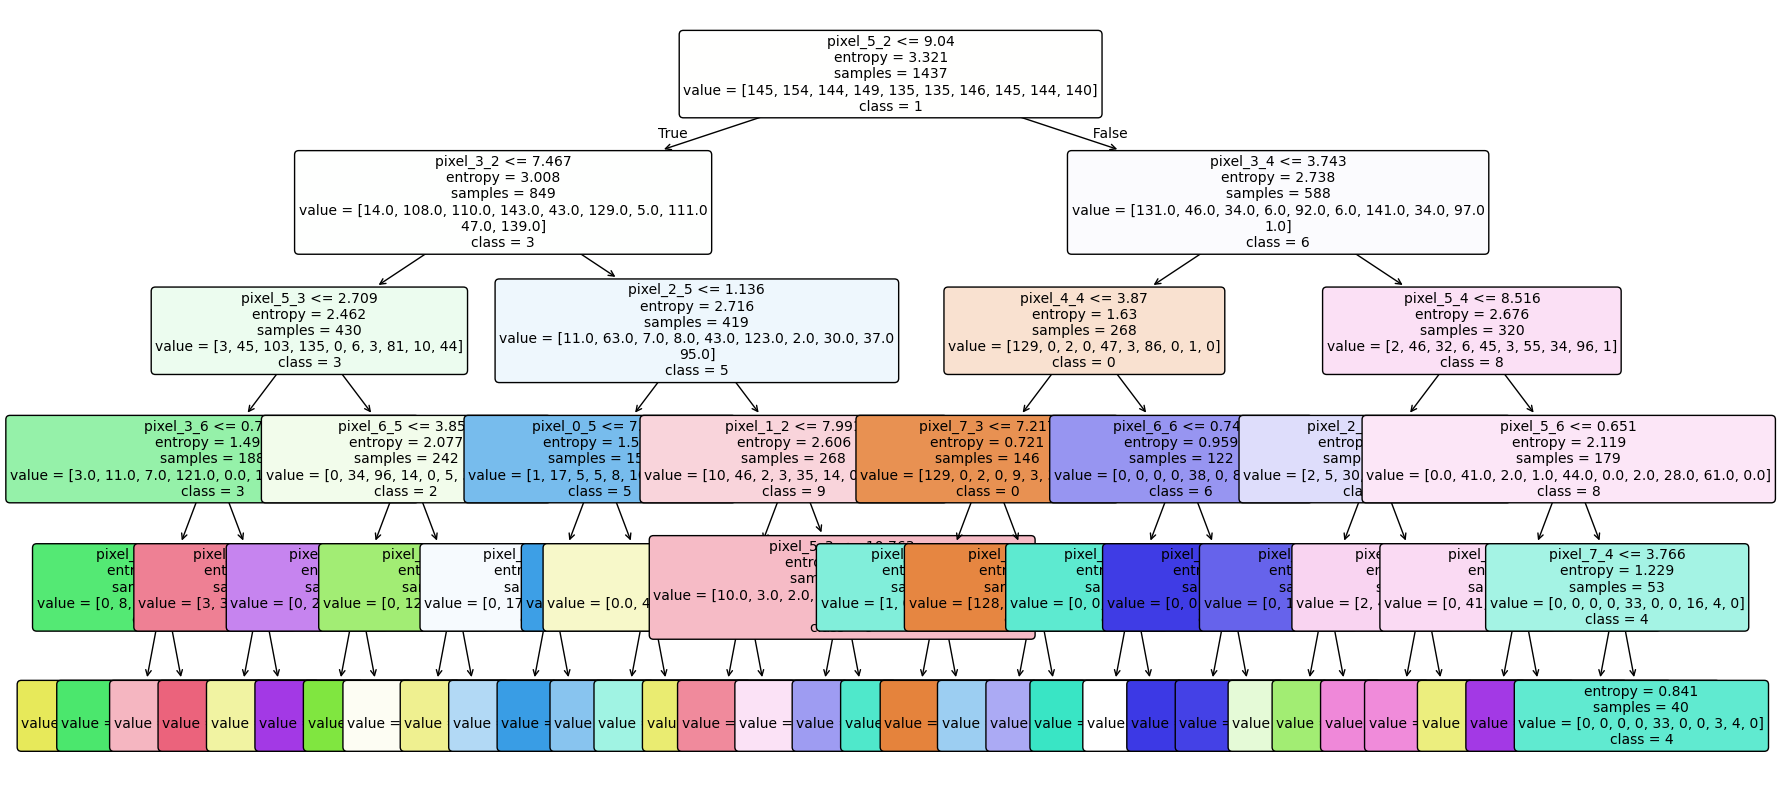

In [34]:
visualize_tree('entropy','random',5,2,2)

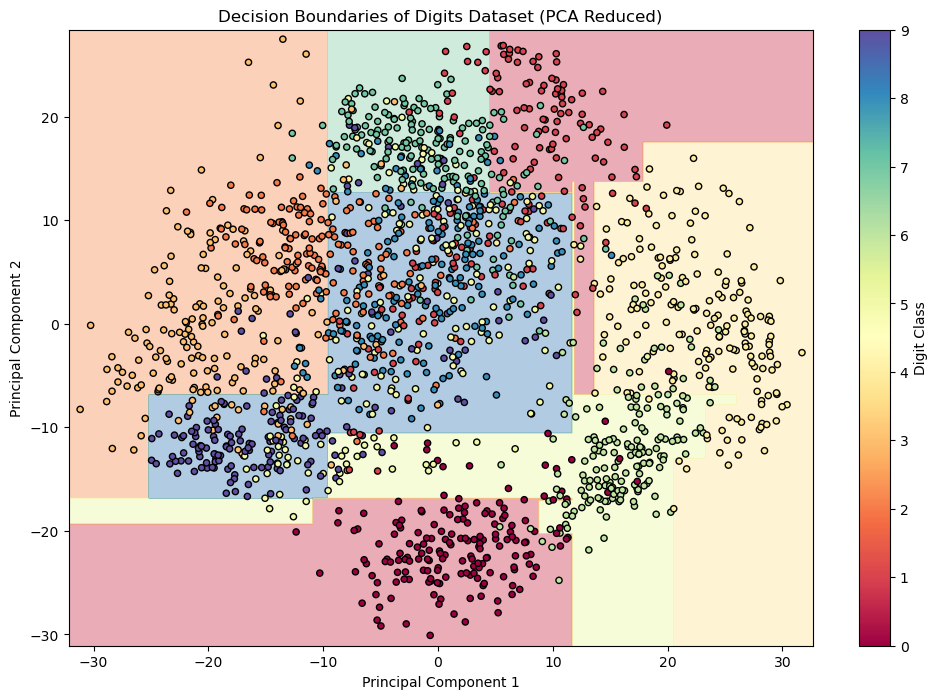

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

digits = load_digits()
X, y = digits.data, digits.target

# 2. Reduce Dimensions (64D -> 2D)
# We must squash the data to 2D to plot it on an X-Y graph
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X)

# 3. Train Decision Tree on the 2D Data
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_reduced, y)

# 4. Create the "Mesh Grid" (The background canvas)
# This creates a grid of empty points covering the entire plot area
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 5. Predict the class for every point in the background grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Plotting
plt.figure(figsize=(12, 8))

# Draw the colored regions (The Decision Boundaries)
plt.contourf(xx, yy, Z, alpha=0.4, cmap='Spectral')

# Draw the actual data points (The Scatter Plot)
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, 
                      s=20, edgecolor='k', cmap='Spectral')

plt.title("Decision Boundaries of Digits Dataset (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.show()